In [ ]:
"""
PIPELINE CNN PARA DETECÇÃO DE GLAUCOMA - VERSÃO ESSENCIAL
Dataset: RIM-ONE DL
"""

# =============================================================================
# 1. IMPORTS E CONFIGURAÇÃO
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from google.colab import drive
from pathlib import Path


In [ ]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

# =============================================================================
# 2. CONFIGURAÇÕES
# =============================================================================
drive.mount('/content/drive')
BASE_PATH = Path('/content/drive/MyDrive/BIP Project Team L')

print("BASE_PATH exists?", BASE_PATH.exists())

TRAIN_DIR = BASE_PATH / 'data/images/training_set'
TEST_DIR  = BASE_PATH / 'data/images/test_set'

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)

# Caminhos dos dados
#TRAIN_DIR = 'data/RIMONE-DL/train'  # ← MUDE AQUI
#TEST_DIR = 'data/RIMONE-DL/test'    # ← MUDE AQUI

# Hiperparâmetros
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.0001
VAL_SPLIT = 0.2
EARLY_STOP_PATIENCE = 10


# Modelo
MODEL_NAME = 'resnet50'  # Opções: resnet50, resnet34, efficientnet_b0
PRETRAINED = True

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_PATH exists? True
TRAIN_DIR: /content/drive/MyDrive/BIP Project Team L/data/images/training_set
TEST_DIR : /content/drive/MyDrive/BIP Project Team L/data/images/test_set


In [ ]:
# =============================================================================
# 3. TRANSFORMAÇÕES DE DADOS
# =============================================================================

# TREINO: com data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2), # era 0.3
    transforms.RandomRotation(degrees=10), # era 15
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2,  # ← adicionei
                           hue=0.05         # ← adicionei (muito leve!)
                          ),
    transforms.ToTensor(),
    # normalização por canal rgb da imagem depois de ter virado tensor, se faz
    # para ter compatibilidade com modelos pre treinados
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# VALIDAÇÃO/TESTE: SEM data augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# =============================================================================
# 4. CARREGAR E DIVIDIR DADOS
# =============================================================================

print("\n" + "="*60)
print("CARREGANDO DADOS")
print("="*60)

# Carregar dataset de treino
full_train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transforms)

print(f"\nTotal de imagens: {len(full_train_dataset)}")
print(f"Classes: {full_train_dataset.classes}")

# Ver distribuição
targets = [label for _, label in full_train_dataset]
class_counts = Counter(targets)
for class_name, class_idx in full_train_dataset.class_to_idx.items():
    count = class_counts[class_idx]
    print(f"  {class_name}: {count} ({count/len(targets)*100:.1f}%)")

# Dividir em train/val (estratificado)
train_idx, val_idx = train_test_split(
    list(range(len(full_train_dataset))),
    test_size=VAL_SPLIT,
    stratify=targets,
    random_state=42
)

print(f"\nSplit: {len(train_idx)} treino / {len(val_idx)} validação")

# Criar subsets
train_subset = Subset(full_train_dataset, train_idx)

val_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=val_test_transforms)
val_subset = Subset(val_dataset, val_idx)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)




CARREGANDO DADOS

Total de imagens: 339
Classes: ['glaucoma', 'normal']
  glaucoma: 120 (35.4%)
  normal: 219 (64.6%)

Split: 271 treino / 68 validação



VISUALIZANDO DATA AUGMENTATION

Visualizando augmentation para classe: glaucoma


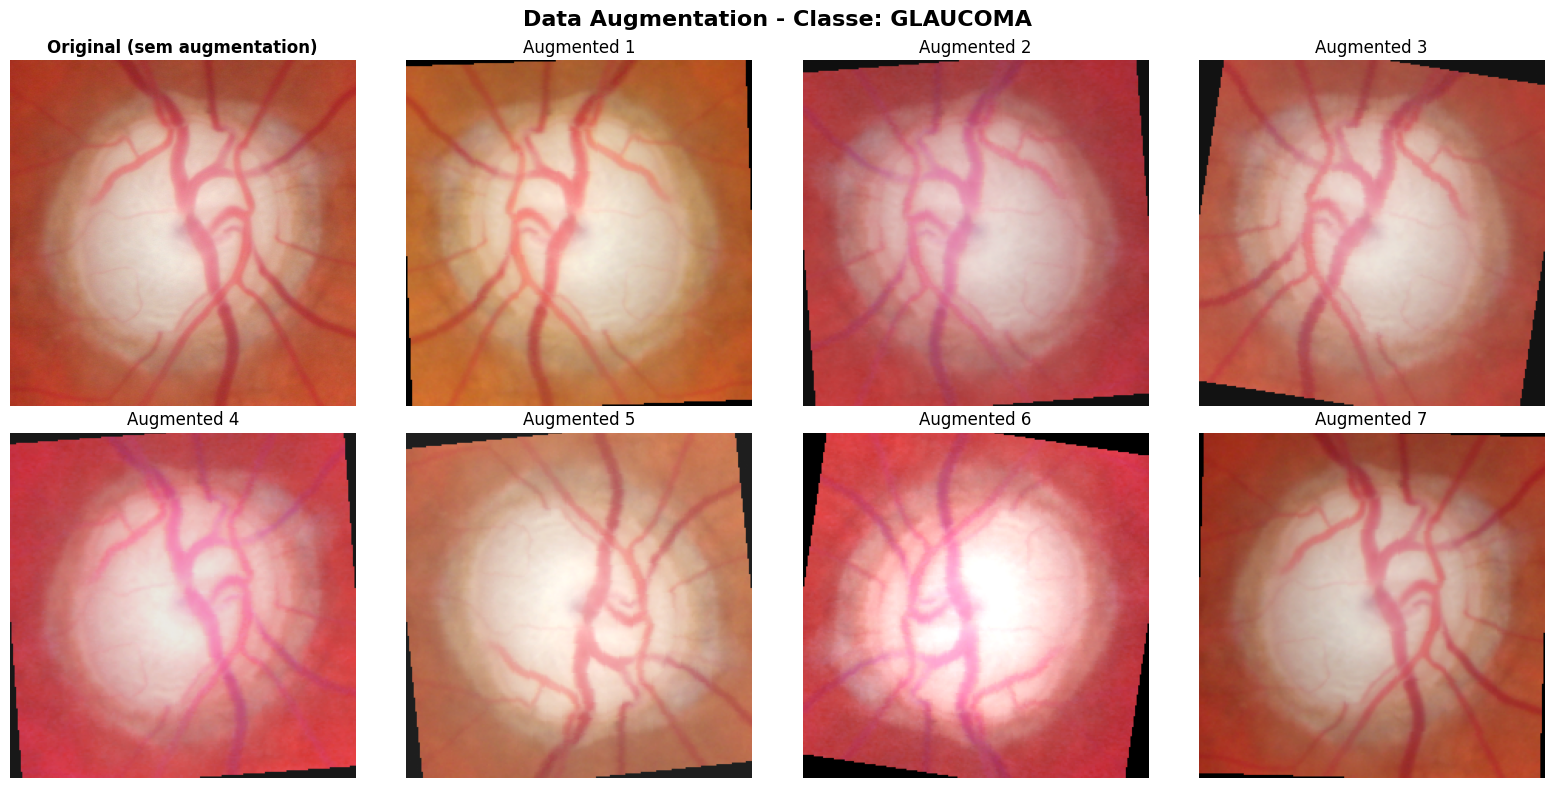


Visualizando augmentation para classe: normal


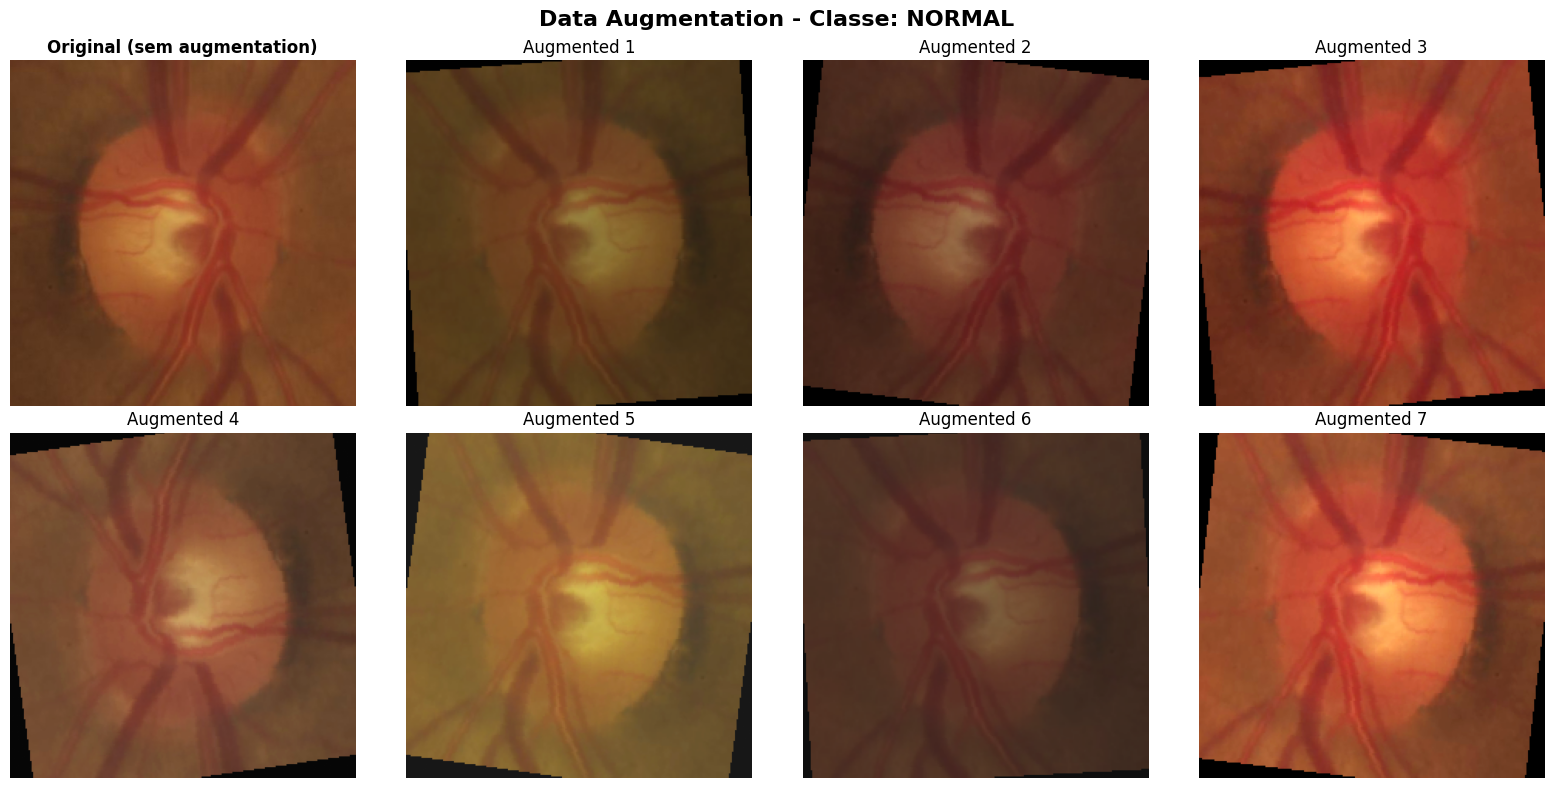


✅ Imagens salvas:
  - augmentation_glaucoma.png
  - augmentation_normal.png

VERIFICAÇÃO:
👀 Olhe as imagens geradas e verifique:
  ✅ O disco óptico ainda está visível?
  ✅ As cores parecem naturais?
  ✅ A imagem não está muito distorcida?
  ✅ As estruturas anatômicas estão preservadas?

Se algo parecer estranho, reduza a intensidade das transformações!


In [ ]:
# =============================================================================
# 4.1 VISUALIZAR DATA AUGMENTATION
# =============================================================================

print("\n" + "="*60)
print("VISUALIZANDO DATA AUGMENTATION")
print("="*60)

from PIL import Image

# Pegar uma imagem de exemplo de cada classe
sample_images = {}
for class_name in full_train_dataset.classes:
    class_idx = full_train_dataset.class_to_idx[class_name]
    # Encontrar primeira imagem desta classe
    for img_path, label in full_train_dataset.samples:
        if label == class_idx:
            sample_images[class_name] = img_path
            break

# Visualizar augmentation para cada classe
for class_name, img_path in sample_images.items():
    print(f"\nVisualizando augmentation para classe: {class_name}")

    # Carregar imagem original
    original_img = Image.open(img_path).convert('RGB')

    # Criar grid de visualização
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    # Mostrar original (sem augmentation)
    axes[0].imshow(original_img)
    axes[0].set_title('Original (sem augmentation)', fontweight='bold')
    axes[0].axis('off')

    # Mostrar 7 versões com augmentation
    for i in range(1, 8):
        augmented = train_transforms(original_img)

        # Denormalizar para visualizar
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = augmented * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)

        axes[i].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')

    plt.suptitle(f'Data Augmentation - Classe: {class_name.upper()}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'augmentation_{class_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Imagens salvas:")
print("  - augmentation_glaucoma.png")
print("  - augmentation_normal.png")

print("\n" + "="*60)
print("VERIFICAÇÃO:")
print("="*60)
print("👀 Olhe as imagens geradas e verifique:")
print("  ✅ O disco óptico ainda está visível?")
print("  ✅ As cores parecem naturais?")
print("  ✅ A imagem não está muito distorcida?")
print("  ✅ As estruturas anatômicas estão preservadas?")
print("\nSe algo parecer estranho, reduza a intensidade das transformações!")

In [ ]:
# =============================================================================
# 5. CRIAR MODELO
# =============================================================================

print("\n" + "="*60)
print("CRIANDO MODELO")
print("="*60)

def get_model(model_name='resnet50', pretrained=True):
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    else:
        raise ValueError(f"Modelo {model_name} não suportado")
    return model

model = get_model(MODEL_NAME, PRETRAINED).to(device)
print(f"Modelo: {MODEL_NAME}")
print(f"Parâmetros: {sum(p.numel() for p in model.parameters()):,}")




CRIANDO MODELO


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modelo: resnet50
Parâmetros: 23,512,130


In [ ]:
# =============================================================================
# 6. LOSS E OPTIMIZER
# =============================================================================

# Class weights para desbalanceamento
class_weights = torch.tensor([
    len(targets) / (2 * class_counts[0]),
    len(targets) / (2 * class_counts[1])
]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01,      # ← Weight decay mais forte
    betas=(0.9, 0.999)) #antes era só Adam



In [ ]:
# =============================================================================
# 7. TREINAMENTO
# =============================================================================

print("\n" + "="*60)
print("TREINANDO")
print("="*60)

best_val_acc = 0.0
patience = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_bal_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # ============ TREINO ============
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc='Train'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ============ VALIDAÇÃO ============
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)
    val_auc = roc_auc_score(all_labels, all_probs)

    # Salvar histórico
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_bal_acc'].append(val_bal_acc)

    # Print
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Bal Acc: {val_bal_acc:.4f}")
    print(f"F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

    # Salvar melhor modelo
    if val_bal_acc > best_val_acc:
        best_val_acc = val_bal_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Modelo salvo! (Bal Acc: {best_val_acc:.4f})")
        patience = 0
    else:
        patience += 1

    # Early stopping
    if patience >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping! Sem melhora por {EARLY_STOP_PATIENCE} épocas")
        break

print("\n" + "="*60)
print(f"TREINAMENTO CONCLUÍDO")
print(f"Melhor Balanced Accuracy: {best_val_acc:.4f}")
print("="*60)




TREINANDO

Epoch 1/50


Val: 100%|██████████| 3/3 [00:01<00:00,  2.65it/s]


Train Loss: 0.5565
Val Loss: 0.5395 | Acc: 0.8235 | Bal Acc: 0.7595
F1: 0.8776 | AUC: 0.9403
✓ Modelo salvo! (Bal Acc: 0.7595)

Epoch 2/50


Val: 100%|██████████| 3/3 [00:01<00:00,  2.88it/s]


Train Loss: 0.3799
Val Loss: 0.4323 | Acc: 0.8824 | Bal Acc: 0.8428
F1: 0.9149 | AUC: 0.9328
✓ Modelo salvo! (Bal Acc: 0.8428)

Epoch 3/50


...

Train Loss: 0.0566
Val Loss: 0.5167 | Acc: 0.9118 | Bal Acc: 0.8750
F1: 0.9362 | AUC: 0.9574

Epoch 18/50


Val: 100%|██████████| 3/3 [00:01<00:00,  2.88it/s]


Train Loss: 0.1091
Val Loss: 1.0515 | Acc: 0.8824 | Bal Acc: 0.8523
F1: 0.9130 | AUC: 0.8949

Epoch 19/50


Val: 100%|██████████| 3/3 [00:01<00:00,  2.89it/s]

Train Loss: 0.0721
Val Loss: 1.0119 | Acc: 0.7941 | Bal Acc: 0.8125
F1: 0.8250 | AUC: 0.9167

Early stopping! Sem melhora por 10 épocas

TREINAMENTO CONCLUÍDO
Melhor Balanced Accuracy: 0.9261


In [ ]:
# =============================================================================
# 8. VISUALIZAR RESULTADOS
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history['val_acc'], label='Val Accuracy')
ax2.plot(history['val_bal_acc'], label='Val Balanced Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_train_dataset.classes,
            yticklabels=full_train_dataset.classes)
plt.title('Confusion Matrix (Validation)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# =============================================================================
# 9. AVALIAR NO TESTE
# =============================================================================

print("\n" + "="*60)
print("AVALIANDO NO TESTE")
print("="*60)

# Carregar melhor modelo
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Dataset de teste
test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=val_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total teste: {len(test_dataset)} imagens")

# Predições
all_preds = []
all_probs = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc='Test'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# Mostrar distribuição
pred_counts = Counter(all_preds)
print(f"\nPredições no teste:")
print(f"  Normal (0): {pred_counts.get(0, 0)}")
print(f"  Glaucoma (1): {pred_counts.get(1, 0)}")




print("\n✅ PIPELINE CONCLUÍDO!")
print("Arquivos gerados:")
print("  - best_model.pth")
print("  - training_curves.png")
print("  - confusion_matrix.png")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



OTIMIZAÇÃO DE THRESHOLD

📊 Métricas com Threshold Padrão (0.5):
  Balanced Accuracy: 0.8302
  Accuracy: 0.8699
  Precision: 0.8505
  Recall/Sensitivity: 0.9681
  F1-Score: 0.9055
  AUC-ROC: 0.9585
  Specificity: 0.6923

🔍 Procurando melhor threshold...

✨ Métricas com Threshold Otimizado (0.985):
  Balanced Accuracy: 0.9083
  Accuracy: 0.9041
  Precision: 0.9545
  Recall/Sensitivity: 0.8936
  F1-Score: 0.9231
  Specificity: 0.9231
  AUC-ROC: 0.9585

📈 GANHOS COM THRESHOLD OTIMIZADO:
  Balanced Accuracy: +0.0782
  Recall: -0.0745
  F1-Score: +0.0176


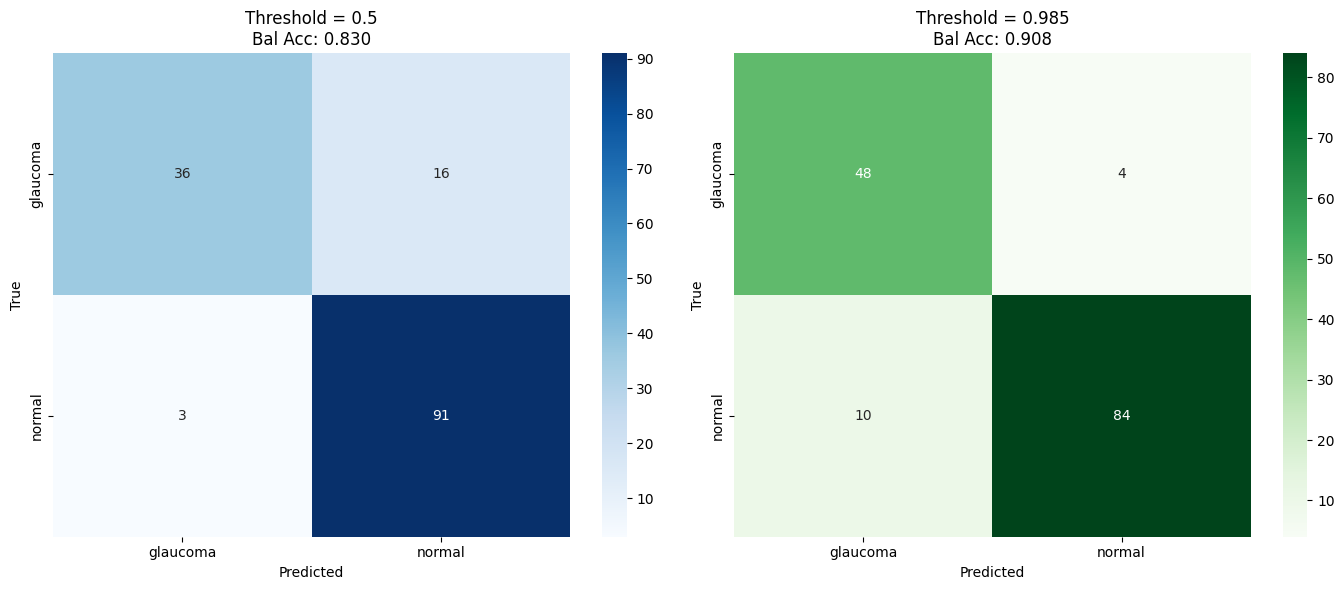

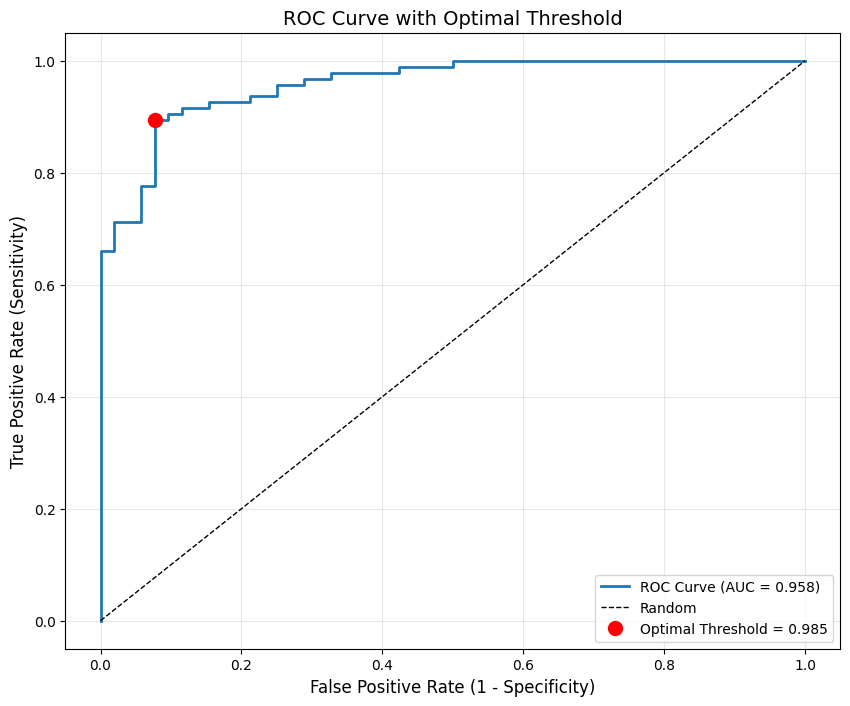

In [ ]:
# =============================================================================
# OTIMIZAÇÃO DE THRESHOLD
# =============================================================================

print("\n" + "="*60)
print("OTIMIZAÇÃO DE THRESHOLD")
print("="*60)

# Obter labels verdadeiras do teste
test_labels = [label for _, label in test_dataset.samples]

# Converter para numpy
all_probs = np.array(all_probs)
test_labels = np.array(test_labels)

# Calcular métricas com threshold padrão (0.5)
default_preds = (all_probs >= 0.5).astype(int)

print("\n📊 Métricas com Threshold Padrão (0.5):")
print(f"  Balanced Accuracy: {balanced_accuracy_score(test_labels, default_preds):.4f}")
print(f"  Accuracy: {accuracy_score(test_labels, default_preds):.4f}")
print(f"  Precision: {precision_score(test_labels, default_preds):.4f}")
print(f"  Recall/Sensitivity: {recall_score(test_labels, default_preds):.4f}")
print(f"  F1-Score: {f1_score(test_labels, default_preds):.4f}")
print(f"  AUC-ROC: {roc_auc_score(test_labels, all_probs):.4f}")

# Calcular especificidade
cm_default = confusion_matrix(test_labels, default_preds)
tn, fp, fn, tp = cm_default.ravel()
specificity_default = tn / (tn + fp)
print(f"  Specificity: {specificity_default:.4f}")

# Encontrar threshold ótimo
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_labels, all_probs)

best_threshold = 0.5
best_bal_acc = 0
best_metrics = {}

print("\n🔍 Procurando melhor threshold...")

for threshold in thresholds:
    preds = (all_probs >= threshold).astype(int)
    bal_acc = balanced_accuracy_score(test_labels, preds)

    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_threshold = threshold

        # Calcular todas as métricas
        cm = confusion_matrix(test_labels, preds)
        tn, fp, fn, tp = cm.ravel()

        best_metrics = {
            'threshold': threshold,
            'balanced_acc': bal_acc,
            'accuracy': accuracy_score(test_labels, preds),
            'precision': precision_score(test_labels, preds),
            'recall': recall_score(test_labels, preds),
            'f1': f1_score(test_labels, preds),
            'specificity': tn / (tn + fp),
            'auc': roc_auc_score(test_labels, all_probs)
        }

print(f"\n✨ Métricas com Threshold Otimizado ({best_threshold:.3f}):")
print(f"  Balanced Accuracy: {best_metrics['balanced_acc']:.4f}")
print(f"  Accuracy: {best_metrics['accuracy']:.4f}")
print(f"  Precision: {best_metrics['precision']:.4f}")
print(f"  Recall/Sensitivity: {best_metrics['recall']:.4f}")
print(f"  F1-Score: {best_metrics['f1']:.4f}")
print(f"  Specificity: {best_metrics['specificity']:.4f}")
print(f"  AUC-ROC: {best_metrics['auc']:.4f}")

# Comparação
print("\n📈 GANHOS COM THRESHOLD OTIMIZADO:")
print(f"  Balanced Accuracy: {best_metrics['balanced_acc'] - balanced_accuracy_score(test_labels, default_preds):+.4f}")
print(f"  Recall: {best_metrics['recall'] - recall_score(test_labels, default_preds):+.4f}")
print(f"  F1-Score: {best_metrics['f1'] - f1_score(test_labels, default_preds):+.4f}")

# Aplicar threshold ótimo
optimized_preds = (all_probs >= best_threshold).astype(int)

# Plotar comparação das matrizes de confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Matriz com threshold padrão
cm1 = confusion_matrix(test_labels, default_preds)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['glaucoma', 'normal'],
            yticklabels=['glaucoma', 'normal'])
ax1.set_title(f'Threshold = 0.5\nBal Acc: {balanced_accuracy_score(test_labels, default_preds):.3f}')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')

# Matriz com threshold otimizado
cm2 = confusion_matrix(test_labels, optimized_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['glaucoma', 'normal'],
            yticklabels=['glaucoma', 'normal'])
ax2.set_title(f'Threshold = {best_threshold:.3f}\nBal Acc: {best_bal_acc:.3f}')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150)
plt.show()

# Plotar curva ROC com threshold ótimo marcado
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {best_metrics["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')

# Marcar threshold ótimo
idx = np.argmin(np.abs(thresholds - best_threshold))
plt.plot(fpr[idx], tpr[idx], 'ro', markersize=10,
         label=f'Optimal Threshold = {best_threshold:.3f}')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve with Optimal Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve_optimal.png', dpi=150)
plt.show()

Test: 100%|██████████| 5/5 [00:02<00:00,  1.85it/s]


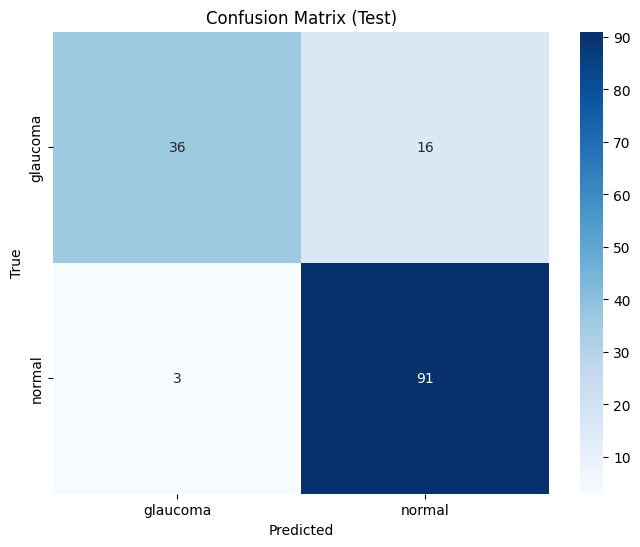

Test Acc: 0.8699
Test Bal Acc: 0.8302
Precision (glaucoma): 0.9231
Recall/Sensibilidade (glaucoma): 0.6923
F1 (glaucoma): 0.7912
AUC (glaucoma): 0.9585


In [ ]:
# =========================
# TESTE: preds + labels
# =========================
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

all_test_preds = []
all_test_labels = []
all_test_probs_glaucoma = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Test'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = outputs.max(1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.numpy())

        # glaucoma é classe 0
        all_test_probs_glaucoma.extend(probs[:, 0].cpu().numpy())

# Matriz de confusão (Teste)
cm_test = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title('Confusion Matrix (Test)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()

# Métricas no teste (glaucoma como classe positiva = 0)
# Para f1_score/precision/recall considerarem glaucoma como positivo, define pos_label=0
from sklearn.metrics import precision_score, recall_score

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_bal_acc = balanced_accuracy_score(all_test_labels, all_test_preds)
test_prec_g = precision_score(all_test_labels, all_test_preds, pos_label=0)
test_rec_g  = recall_score(all_test_labels, all_test_preds, pos_label=0)
test_f1_g   = f1_score(all_test_labels, all_test_preds, pos_label=0)
test_auc_g  = roc_auc_score((np.array(all_test_labels)==0).astype(int), all_test_probs_glaucoma)

print(f"Test Acc: {test_acc:.4f}")
print(f"Test Bal Acc: {test_bal_acc:.4f}")
print(f"Precision (glaucoma): {test_prec_g:.4f}")
print(f"Recall/Sensibilidade (glaucoma): {test_rec_g:.4f}")
print(f"F1 (glaucoma): {test_f1_g:.4f}")
print(f"AUC (glaucoma): {test_auc_g:.4f}")


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_labels_val = []
all_probs_val = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        all_probs_val.extend(probs)
        all_labels_val.extend(labels.numpy())

val_auc_best = roc_auc_score(all_labels_val, all_probs_val)
print(f"AUC (val) do melhor modelo salvo: {val_auc_best:.4f}")


AUC (val) do melhor modelo salvo: 0.9517


#SEGUNDA ABORDAGEM

In [ ]:
"""
PIPELINE CNN COM K-FOLD CROSS-VALIDATION
Dataset: RIM-ONE DL
"""

# =============================================================================
# 1. IMPORTS (mantém igual)
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

# =============================================================================
# 2. CONFIGURAÇÕES (mantém igual + adiciona K_FOLDS)
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = Path('/content/drive/MyDrive/BIP Project Team L')
TRAIN_DIR = BASE_PATH / 'data/images/training_set'
TEST_DIR = BASE_PATH / 'data/images/test_set'

# Hiperparâmetros
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.0001
EARLY_STOP_PATIENCE = 10

# NOVO: Configuração de Cross-Validation
K_FOLDS = 5  # Número de folds

# Modelo
MODEL_NAME = 'resnet50'
PRETRAINED = True

print(f"\n{'='*60}")
print(f"CONFIGURAÇÃO: {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*60}")



Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

CONFIGURAÇÃO: 5-Fold Cross-Validation


In [ ]:
# =============================================================================
# 3. TRANSFORMAÇÕES (mantém igual)
# =============================================================================

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2), # era 0.3
    transforms.RandomRotation(degrees=10), # era 15
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2,  # ← adicionei
                           hue=0.05         # ← adicionei (muito leve!)
                          ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



In [ ]:
# =============================================================================
# 4. CARREGAR DADOS (SEM SPLIT - CV fará isso)
# =============================================================================

print("\n" + "="*60)
print("CARREGANDO DADOS")
print("="*60)

# Carregar dataset completo
full_train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transforms)

print(f"\nTotal de imagens: {len(full_train_dataset)}")
print(f"Classes: {full_train_dataset.classes}")

# Obter labels
targets = [label for _, label in full_train_dataset]
class_counts = Counter(targets)

for class_name, class_idx in full_train_dataset.class_to_idx.items():
    count = class_counts[class_idx]
    print(f"  {class_name}: {count} ({count/len(targets)*100:.1f}%)")

# Class weights (calcular uma vez)
class_weights = torch.tensor([
    len(targets) / (2 * class_counts[0]),
    len(targets) / (2 * class_counts[1])
], dtype=torch.float).to(device)




CARREGANDO DADOS

Total de imagens: 339
Classes: ['glaucoma', 'normal']
  glaucoma: 120 (35.4%)
  normal: 219 (64.6%)


In [ ]:
# =============================================================================
# 5. FUNÇÃO PARA CRIAR MODELO
# =============================================================================

def get_model(model_name='resnet50', pretrained=True):
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    else:
        raise ValueError(f"Modelo {model_name} não suportado")
    return model



In [ ]:
# =============================================================================
# 6. FUNÇÕES DE TREINO E VALIDAÇÃO
# =============================================================================

def train_epoch(model, loader, criterion, optimizer, device, clip_value=None):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        if clip_value:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    metrics = {
        'loss': running_loss / len(loader),
        'accuracy': accuracy_score(all_labels, all_preds),
        'balanced_accuracy': balanced_accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall': recall_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'auc': roc_auc_score(all_labels, all_probs)
    }

    return metrics, all_preds, all_labels, all_probs



In [ ]:
# =============================================================================
# 7. CROSS-VALIDATION LOOP
# =============================================================================

print("\n" + "="*60)
print(f"INICIANDO {K_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

# Preparar K-Fold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Armazenar resultados de cada fold
cv_results = {
    'fold': [],
    'balanced_acc': [],
    'accuracy': [],
    'f1_score': [],
    'auc': [],
    'precision': [],
    'recall': [],
    'optimal_threshold': [],
    'train_history': []
}

# Armazenar modelos treinados para ensemble
trained_models = []

# Iterar pelos folds
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(full_train_dataset)), targets)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/{K_FOLDS}")
    print(f"{'='*60}")

    # Criar datasets para este fold
    train_subset = Subset(full_train_dataset, train_idx)

    val_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=val_test_transforms)
    val_subset = Subset(val_dataset, val_idx)

    # DataLoaders
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Train: {len(train_subset)} | Val: {len(val_subset)}")

    # Criar modelo novo para este fold
    model = get_model(MODEL_NAME, PRETRAINED).to(device)

    # Loss e Optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5)

    # Treinar este fold
    best_val_acc = 0
    patience = 0
    fold_history = {'train_loss': [], 'val_bal_acc': []}

    for epoch in range(NUM_EPOCHS):
        # Treino
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validação
        val_metrics, val_preds, val_labels, val_probs = validate(model, val_loader, criterion, device)

        # Histórico
        fold_history['train_loss'].append(train_loss)
        fold_history['val_bal_acc'].append(val_metrics['balanced_accuracy'])

        # Scheduler
        scheduler.step(val_metrics['balanced_accuracy'])

        # Print progress (a cada 5 épocas)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Bal Acc: {val_metrics['balanced_accuracy']:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Salvar melhor modelo
        if val_metrics['balanced_accuracy'] > best_val_acc:
            best_val_acc = val_metrics['balanced_accuracy']
            torch.save(model.state_dict(), f'best_model_fold{fold}.pth')
            best_probs = val_probs.copy()
            best_labels = val_labels.copy()
            patience = 0
        else:
            patience += 1

        # Early stopping
        if patience >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Carregar melhor modelo deste fold
    model.load_state_dict(torch.load(f'best_model_fold{fold}.pth'))
    model.eval()
    trained_models.append(model)

    # Encontrar threshold ótimo para este fold
    fpr, tpr, thresholds = roc_curve(best_labels, best_probs)
    best_threshold = 0.5
    best_bal_acc_threshold = 0

    for threshold in thresholds:
        preds = (np.array(best_probs) >= threshold).astype(int)
        bal_acc = balanced_accuracy_score(best_labels, preds)
        if bal_acc > best_bal_acc_threshold:
            best_bal_acc_threshold = bal_acc
            best_threshold = threshold

    optimized_preds = (np.array(best_probs) >= best_threshold).astype(int)

    # Salvar resultados deste fold
    cv_results['fold'].append(fold + 1)
    cv_results['balanced_acc'].append(best_bal_acc_threshold)
    cv_results['accuracy'].append(accuracy_score(best_labels, optimized_preds))
    cv_results['f1_score'].append(f1_score(best_labels, optimized_preds))
    cv_results['auc'].append(roc_auc_score(best_labels, best_probs))
    cv_results['precision'].append(precision_score(best_labels, optimized_preds))
    cv_results['recall'].append(recall_score(best_labels, optimized_preds))
    cv_results['optimal_threshold'].append(best_threshold)
    cv_results['train_history'].append(fold_history)

    print(f"\n{'='*60}")
    print(f"FOLD {fold+1} RESULTS:")
    print(f"{'='*60}")
    print(f"Balanced Accuracy: {best_bal_acc_threshold:.4f}")
    print(f"Optimal Threshold: {best_threshold:.3f}")
    print(f"F1-Score: {f1_score(best_labels, optimized_preds):.4f}")
    print(f"AUC: {roc_auc_score(best_labels, best_probs):.4f}")




INICIANDO 5-FOLD CROSS-VALIDATION

FOLD 1/5
Train: 271 | Val: 68


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50 | Train Loss: 0.5411 | Val Bal Acc: 0.7841 | LR: 1.00e-04


Epoch 5/50 | Train Loss: 0.1580 | Val Bal Acc: 0.7860 | LR: 1.00e-04


Epoch 10/50 | Train Loss: 0.0799 | Val Bal Acc: 0.8314 | LR: 1.00e-04


...

Epoch 5/50 | Train Loss: 0.2326 | Val Bal Acc: 0.8217 | LR: 1.00e-04


Epoch 10/50 | Train Loss: 0.1200 | Val Bal Acc: 0.8910 | LR: 1.00e-04


Epoch 15/50 | Train Loss: 0.0273 | Val Bal Acc: 0.8842 | LR: 1.00e-04


Epoch 20/50 | Train Loss: 0.0519 | Val Bal Acc: 0.8009 | LR: 5.00e-05


Early stopping at epoch 23

FOLD 5 RESULTS:
Balanced Accuracy: 0.9142
Optimal Threshold: 0.551
F1-Score: 0.9425
AUC: 0.9651



CROSS-VALIDATION SUMMARY

Balanced Accuracy: 0.9010 ± 0.0347
Accuracy: 0.9086 ± 0.0364
F1-Score: 0.9286 ± 0.0299
AUC: 0.9483 ± 0.0233
Precision: 0.9315 ± 0.0251
Recall: 0.9271 ± 0.0484
Optimal Threshold: 0.594 ± 0.184


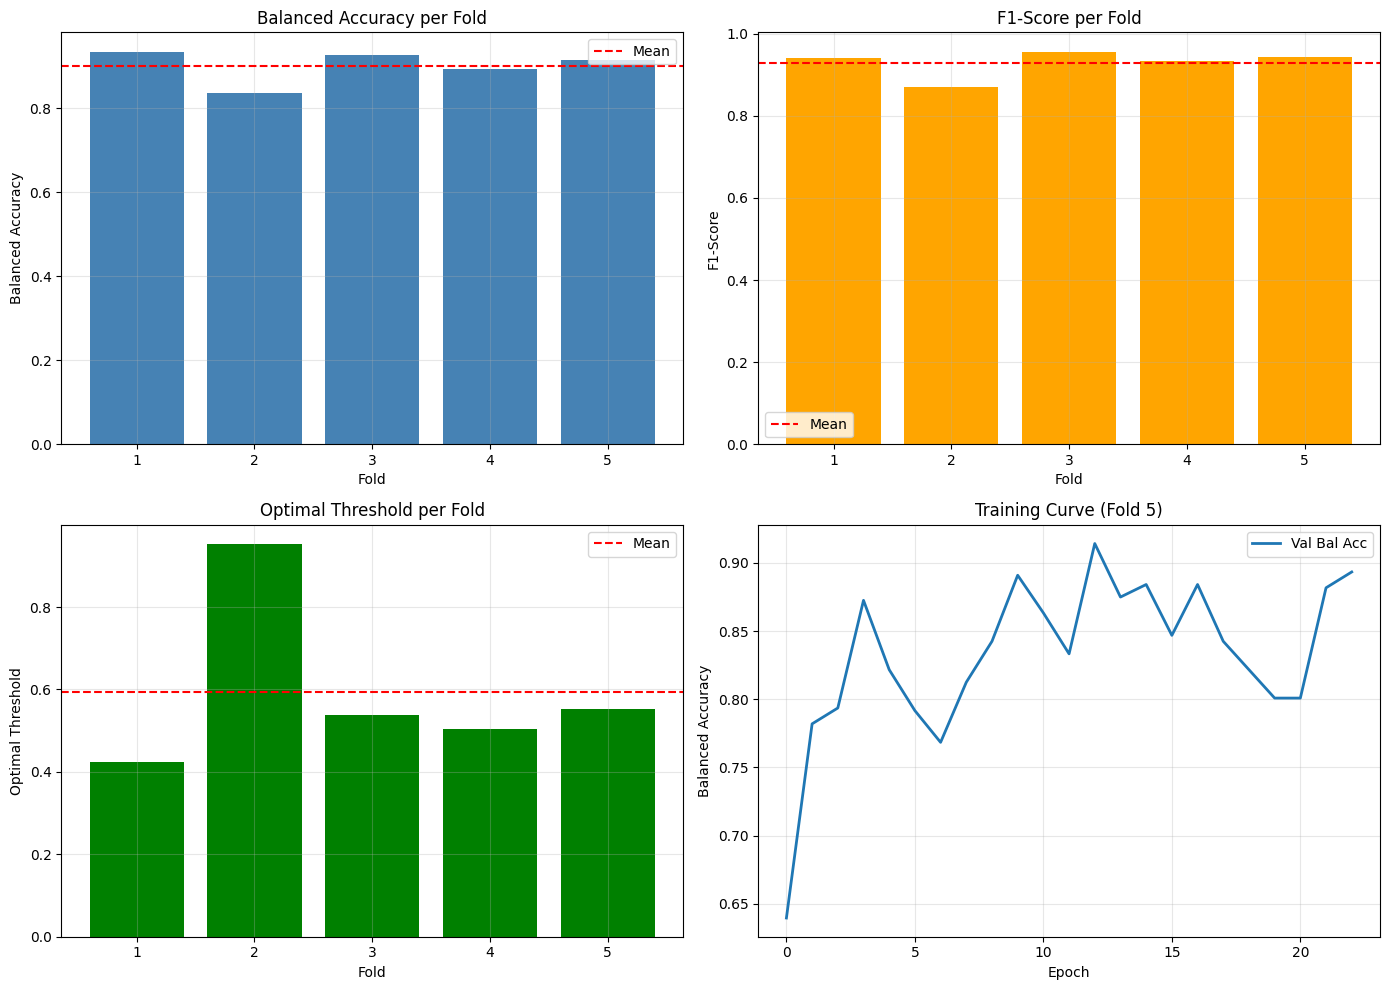


✅ Arquivo salvo: cv_results.png


In [ ]:
# =============================================================================
# 8. RESULTADOS DO CROSS-VALIDATION
# =============================================================================

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)

print(f"\nBalanced Accuracy: {np.mean(cv_results['balanced_acc']):.4f} ± {np.std(cv_results['balanced_acc']):.4f}")
print(f"Accuracy: {np.mean(cv_results['accuracy']):.4f} ± {np.std(cv_results['accuracy']):.4f}")
print(f"F1-Score: {np.mean(cv_results['f1_score']):.4f} ± {np.std(cv_results['f1_score']):.4f}")
print(f"AUC: {np.mean(cv_results['auc']):.4f} ± {np.std(cv_results['auc']):.4f}")
print(f"Precision: {np.mean(cv_results['precision']):.4f} ± {np.std(cv_results['precision']):.4f}")
print(f"Recall: {np.mean(cv_results['recall']):.4f} ± {np.std(cv_results['recall']):.4f}")
print(f"Optimal Threshold: {np.mean(cv_results['optimal_threshold']):.3f} ± {np.std(cv_results['optimal_threshold']):.3f}")

# Plotar resultados por fold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Balanced Accuracy por fold
axes[0, 0].bar(cv_results['fold'], cv_results['balanced_acc'], color='steelblue')
axes[0, 0].axhline(np.mean(cv_results['balanced_acc']), color='red', linestyle='--', label='Mean')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('Balanced Accuracy')
axes[0, 0].set_title('Balanced Accuracy per Fold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# F1-Score por fold
axes[0, 1].bar(cv_results['fold'], cv_results['f1_score'], color='orange')
axes[0, 1].axhline(np.mean(cv_results['f1_score']), color='red', linestyle='--', label='Mean')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('F1-Score per Fold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Threshold ótimo por fold
axes[1, 0].bar(cv_results['fold'], cv_results['optimal_threshold'], color='green')
axes[1, 0].axhline(np.mean(cv_results['optimal_threshold']), color='red', linestyle='--', label='Mean')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Optimal Threshold')
axes[1, 0].set_title('Optimal Threshold per Fold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Curvas de treino do último fold
axes[1, 1].plot(cv_results['train_history'][-1]['val_bal_acc'], label='Val Bal Acc', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Balanced Accuracy')
axes[1, 1].set_title(f'Training Curve (Fold {K_FOLDS})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Arquivo salvo: cv_results.png")



In [ ]:
# =============================================================================
# 8.5. ESCOLHER E SALVAR MELHOR MODELO ÚNICO
# =============================================================================

print("\n" + "="*60)
print("SELECIONANDO MELHOR MODELO ÚNICO")
print("="*60)

# Encontrar melhor fold
best_fold_idx = np.argmax(cv_results['balanced_acc'])
best_fold_num = best_fold_idx + 1

print(f"\nResultados de todos os folds:")
for i in range(K_FOLDS):
    print(f"  Fold {i+1}: Bal Acc = {cv_results['balanced_acc'][i]:.4f}, "
          f"F1 = {cv_results['f1_score'][i]:.4f}, "
          f"Threshold = {cv_results['optimal_threshold'][i]:.3f}")

print(f"\n🏆 MELHOR FOLD: {best_fold_num}")
print(f"   Balanced Accuracy: {cv_results['balanced_acc'][best_fold_idx]:.4f}")
print(f"   F1-Score: {cv_results['f1_score'][best_fold_idx]:.4f}")
print(f"   AUC: {cv_results['auc'][best_fold_idx]:.4f}")
print(f"   Optimal Threshold: {cv_results['optimal_threshold'][best_fold_idx]:.3f}")

# Salvar como modelo geral
import shutil
shutil.copy(
    f'best_model_fold{best_fold_idx}.pth',
    'best_model_overall.pth'
)

print(f"\n✅ Melhor modelo único salvo: best_model_overall.pth")
print(f"   (Fold {best_fold_num} com Bal Acc = {cv_results['balanced_acc'][best_fold_idx]:.4f})")


SELECIONANDO MELHOR MODELO ÚNICO

Resultados de todos os folds:
  Fold 1: Bal Acc = 0.9337, F1 = 0.9412, Threshold = 0.424
  Fold 2: Bal Acc = 0.8371, F1 = 0.8706, Threshold = 0.952
  Fold 3: Bal Acc = 0.9261, F1 = 0.9556, Threshold = 0.538
  Fold 4: Bal Acc = 0.8939, F1 = 0.9333, Threshold = 0.503
  Fold 5: Bal Acc = 0.9142, F1 = 0.9425, Threshold = 0.551

🏆 MELHOR FOLD: 1
   Balanced Accuracy: 0.9337
   F1-Score: 0.9412
   AUC: 0.9669
   Optimal Threshold: 0.424

✅ Melhor modelo único salvo: best_model_overall.pth
   (Fold 1 com Bal Acc = 0.9337)



AVALIANDO ENSEMBLE NO TESTE
Total teste: 146 imagens
Predições do modelo Fold 1...


Fold 1: 100%|██████████| 5/5 [00:02<00:00,  2.30it/s]


Predições do modelo Fold 2...


Fold 2: 100%|██████████| 5/5 [00:02<00:00,  2.40it/s]


Predições do modelo Fold 3...


...

Predições do modelo Fold 4...


Fold 4: 100%|██████████| 5/5 [00:02<00:00,  2.27it/s]


Predições do modelo Fold 5...


Fold 5: 100%|██████████| 5/5 [00:03<00:00,  1.48it/s]



THRESHOLD (baseado no Cross-Validation):
Threshold médio: 0.587
Desvio padrão: 0.145

Thresholds encontrados no CV:
  Fold 1: 0.500
  Fold 2: 0.450
  Fold 3: 0.584
  Fold 4: 0.539
  Fold 5: 0.863

ENSEMBLE RESULTS (TEST SET)
Threshold usado: 0.587 (média do CV)
Balanced Accuracy: 0.8891
Accuracy: 0.8904
Precision: 0.9333
Recall: 0.8936
F1-Score: 0.9130
Specificity: 0.8846
AUC: 0.9646


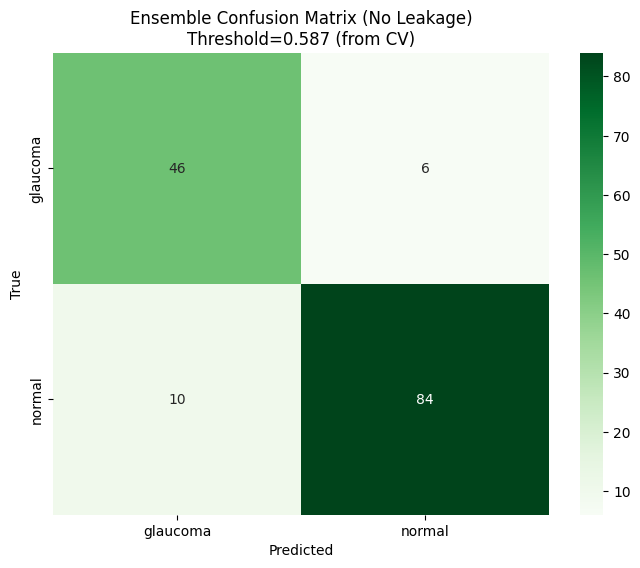


✅ PIPELINE COMPLETO COM CV!
✅ 5 modelos treinados e salvos
✅ Ensemble avaliado no teste (SEM data leakage)


In [ ]:
# =============================================================================
# 9. ENSEMBLE NO TESTE (CORRIGIDO - SEM DATA LEAKAGE)
# =============================================================================

print("\n" + "="*60)
print("AVALIANDO ENSEMBLE NO TESTE")
print("="*60)

# Carregar dataset de teste
test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=val_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total teste: {len(test_dataset)} imagens")

# ✅ Fazer predições com ensemble (média dos K modelos)
ensemble_probs = []

for fold, model in enumerate(trained_models):
    print(f"Predições do modelo Fold {fold+1}...")
    model.eval()
    fold_probs = []

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc=f'Fold {fold+1}'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            fold_probs.extend(probs[:, 1].cpu().numpy())

    ensemble_probs.append(fold_probs)

# Média das probabilidades
final_probs = np.mean(ensemble_probs, axis=0)

# Obter labels do teste
test_labels = np.array([label for _, label in test_dataset.samples])

# ✅ CORREÇÃO: Usar threshold médio do CV (NÃO otimizar no teste!)
optimal_threshold = np.mean(cv_results['optimal_threshold'])

print(f"\n{'='*60}")
print(f"THRESHOLD (baseado no Cross-Validation):")
print(f"{'='*60}")
print(f"Threshold médio: {optimal_threshold:.3f}")
print(f"Desvio padrão: {np.std(cv_results['optimal_threshold']):.3f}")
print(f"\nThresholds encontrados no CV:")
for i, thresh in enumerate(cv_results['optimal_threshold'], 1):
    print(f"  Fold {i}: {thresh:.3f}")

# ✅ Aplicar threshold do CV (não otimizar!)
final_preds = (final_probs >= optimal_threshold).astype(int)

# Calcular métricas finais
cm = confusion_matrix(test_labels, final_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*60}")
print(f"ENSEMBLE RESULTS (TEST SET)")
print(f"{'='*60}")
print(f"Threshold usado: {optimal_threshold:.3f} (média do CV)")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_labels, final_preds):.4f}")
print(f"Accuracy: {accuracy_score(test_labels, final_preds):.4f}")
print(f"Precision: {precision_score(test_labels, final_preds):.4f}")
print(f"Recall: {recall_score(test_labels, final_preds):.4f}")
print(f"F1-Score: {f1_score(test_labels, final_preds):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")
print(f"AUC: {roc_auc_score(test_labels, final_probs):.4f}")

# Matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['glaucoma', 'normal'],
            yticklabels=['glaucoma', 'normal'])
plt.title(f'Ensemble Confusion Matrix (No Leakage)\nThreshold={optimal_threshold:.3f} (from CV)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('ensemble_confusion_matrix_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ PIPELINE COMPLETO COM CV!")
print(f"✅ {K_FOLDS} modelos treinados e salvos")
print("✅ Ensemble avaliado no teste (SEM data leakage)")